# Toy Gaussian model: anisotropic features + ridge

$x \sim \mathcal{N}(0,\Sigma)$, $\Sigma = \mathrm{diag}(\lambda_k)$, $\lambda_k \sim k^{-a}$ (spectrum shaped like an EFP/Legendre-degree decay). Ridge regression, matching the setup in [Atanasov, Zavatone-Veth, Pehlevan (2405.00592)](https://arxiv.org/abs/2405.00592).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy.special import eval_legendre
from scipy.optimize import brentq
from sklearn.model_selection import train_test_split
from RegressFunctions import *

# Sampler, Ridge, and Sweep

In [2]:
### Define Sampler
def sample(N, lam, w_true, sigma):
    P = len(lam)
    X = rng.standard_normal((N, P)) * np.sqrt(lam)
    y = X @ w_true + rng.standard_normal(N) * sigma
    return X, y


# Regress 
# def ridge_fit_np(X, y, r): 
#     N, P = X.shape
#     A = X.T @ X / N + r * np.eye(P)
#     b = X.T @ y / N
#     return np.linalg.solve(A, b)

# def ridge_fit(X, y, r, pushthru=True):
#     N, P = X.shape
#     if r==0: 
#         return torch.linalg.lstsq(X, y).solution
#     if pushthru==True: 
#         A = X @ X.T + r * N * torch.eye(N, dtype=X.dtype, device=X.device)
#         return X.T @ torch.linalg.solve(A, y)
#     A = X.T @ X / N + r * torch.eye(P, dtype=X.dtype, device=X.device)
#     b = X.T @ y / N
#     return torch.linalg.solve(A, b)


def run_sweep(X, y, w_true, r, Ns, n_repeats):
    excess_loss = []
    X = torch.as_tensor(X, dtype=torch.float64)
    y = torch.as_tensor(y, dtype=torch.float64)
    for i, N in enumerate(Ns):
        print(f'on N {i} out of {len(Ns)}')
        losses = []
        w_true = torch.as_tensor(w_true, dtype=torch.float64)
        for _ in range(n_repeats(N)):
            X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=N)
            w_hat = ridge_fit(X_train, y_train, r)
            losses.append(torch.mean((X_test @ (w_hat - w_true)) ** 2).item())
        excess_loss.append(np.mean(losses))
    return np.array(excess_loss)


# UNDERPARAMETERIZED -- Spectra, Sample, Regress

In [21]:
##########################
## Toy Spectrum ~ k^-a ##
##########################
rng = np.random.default_rng(0)

P = 50            # feature dimension
a = 8.           # spectral decay exponent
sigma = 0.5       # noise std

k = np.arange(1, P + 1)
lam = k ** (-a)     # Sigma = diag(lam)

#######################
## Legendre Spectrum ##
#######################
P_leg = 50 
k_leg = np.arange(1, P_leg + 1)

def legendre_features(x):
    return eval_legendre(k_leg[None, :], x[:, None])

x_pool = rng.uniform(-1.0, 1.0, size=500_000)
Phi_pool = legendre_features(x_pool)
Sigma_leg_hat = np.cov(Phi_pool, rowvar=False, bias=True)
lam_leg = np.linalg.eigh(Sigma_leg_hat)[0][::-1]

##############################
## Legendre (norm) Spectrum ##
##############################
P_leg_norm = 50 
k_leg_norm = np.arange(1, P_leg + 1)

def legendre_norm_features(x):
    return np.sqrt(2*k_leg_norm+1)*eval_legendre(k_leg_norm[None, :], x[:, None])

x_pool_norm = rng.uniform(-1.0, 1.0, size=500_000)
Phi_pool_norm = legendre_norm_features(x_pool_norm)
Sigma_leg_norm_hat = np.cov(Phi_pool_norm, rowvar=False, bias=True)
lam_leg_norm = np.linalg.eigh(Sigma_leg_norm_hat)[0][::-1]
print(np.shape(lam_leg))

(50,)


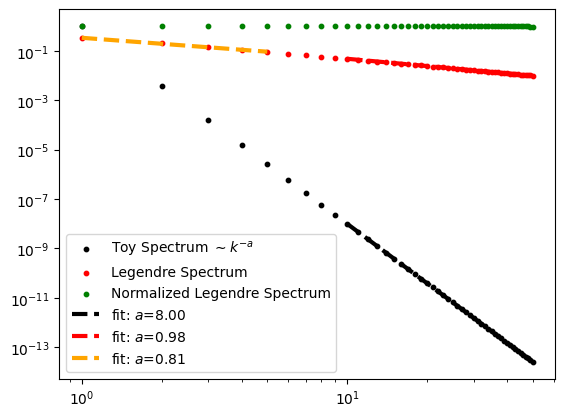

In [22]:
# Plot Spectra
kmin, kmax = 10, 50
mask = (k >= kmin) & (k <= kmax)
mask2 = (k >= 1) & (k <= 5)

a_fit, c_fit = np.polyfit(np.log(k[mask]), np.log(lam[mask]), 1)
a_leg_fit, c_leg_fit = np.polyfit(np.log(k[mask]), np.log(lam_leg[mask]), 1)
a_leg_fit2, c_leg_fit2 = np.polyfit(np.log(k[mask2]), np.log(lam_leg[mask2]), 1)

plt.scatter(k, lam, s=10, color='k')
plt.scatter(k, lam_leg, s=10, color='r')
plt.scatter(k, lam_leg_norm, s=10, color='g')
plt.plot(k[mask], np.exp(c_fit) * k[mask]**a_fit, 'k--', lw=3)
plt.plot(k[mask], np.exp(c_leg_fit) * k[mask]**a_leg_fit, 'r--', lw=3)
plt.plot(k[mask2], np.exp(c_leg_fit2) * k[mask2]**a_leg_fit2, color='orange', linestyle='--', lw=3)
plt.xscale('log'); plt.yscale('log')
plt.legend([r'Toy Spectrum $\sim k^{-a}$', 
            'Legendre Spectrum','Normalized Legendre Spectrum',
            f'fit: $a$={-a_fit:.2f}', f'fit: $a$={-a_leg_fit:.2f}',
            f'fit: $a$={-a_leg_fit2:.2f}'])

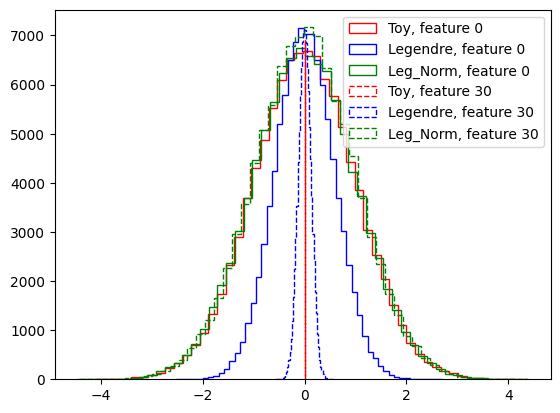

In [23]:
### Plot Samples for a given feature direction ... 

w_true = rng.standard_normal(P)

sigma = 0.5

X_toy, y_toy = sample(100_000, lam, w_true, sigma)
X_leg, y_leg = sample(100_000, lam_leg, w_true, sigma)
X_leg_norm, y_leg_norm = sample(100_000, lam_leg_norm, w_true, sigma)

feature = [0, 30]; bins = 50
plt.hist(X_toy[:, feature[0]], bins=bins, histtype='step', color='r');
plt.hist(X_leg[:, feature[0]], bins=bins, histtype='step', color='b');
plt.hist(X_leg_norm[:, feature[0]], bins=bins, histtype='step', color='g');

plt.hist(X_toy[:, feature[1]], bins=bins, histtype='step', color='r', linestyle='--');
plt.hist(X_leg[:, feature[1]], bins=bins, histtype='step', color='b', linestyle='--');
plt.hist(X_leg_norm[:, feature[1]], bins=bins, histtype='step', color='g', linestyle='--');

plt.legend(['Toy, feature 0', 'Legendre, feature 0', 'Leg_Norm, feature 0',
            'Toy, feature 30', 'Legendre, feature 30', 'Leg_Norm, feature 30'])


In [24]:
## Run Ridge Regression 
Ns = np.round(np.logspace(1, 4.5, 50)).astype(int)
n_repeats = lambda N: max(int(5000/N), 50) 

λs = [0, 1e-5, 1e-2]
excess_loss_toy, excess_loss_leg, excess_loss_leg_norm = {}, {}, {}
for λ in λs: 
    print(f'λ = {λ}')
    excess_loss_toy[λ]      = run_regression_sweep(X_toy, y_toy, Ns, λ, n_repeats, test_size=0.2, w_true=w_true)
    excess_loss_leg[λ]      = run_regression_sweep(X_leg, y_leg, Ns, λ, n_repeats, test_size=0.2, w_true=w_true)
    excess_loss_leg_norm[λ] = run_regression_sweep(X_leg_norm, y_leg_norm, Ns, λ, n_repeats, test_size=0.2, w_true=w_true)


λ = 0
      10  |  3.796742
      12  |  3.280785
      14  |  4.092295
      16  |  3.509622
      19  |  2.661451
      23  |  2.977307
      27  |  2.446758
      32  |  2.743389
      37  |  2.581490
      44  |  3.973209
      52  |  12.462236
      61  |  1.347723
      72  |  0.643318
      85  |  0.457542
     100  |  0.280632
     118  |  0.208755
     139  |  0.169008
     164  |  0.129238
     193  |  0.105693
     228  |  0.088745
     268  |  0.066810
     316  |  0.052885
     373  |  0.047696
     439  |  0.041815
     518  |  0.030330
     611  |  0.026145
     720  |  0.022438
     848  |  0.018211
    1000  |  0.014507
    1179  |  0.012927
    1389  |  0.012042
    1638  |  0.009076
    1931  |  0.007897
    2276  |  0.006757
    2683  |  0.005653
    3162  |  0.004911
    3728  |  0.004129
    4394  |  0.003331
    5179  |  0.002901
    6105  |  0.002568
    7197  |  0.002082
    8483  |  0.001778
   10000  |  0.001476
   11788  |  0.001223
   13895  |  0.001019
   

floor = 0.008077091850845637


Text(2000.0, 20.0, '$\\lambda=10^{-2}$')

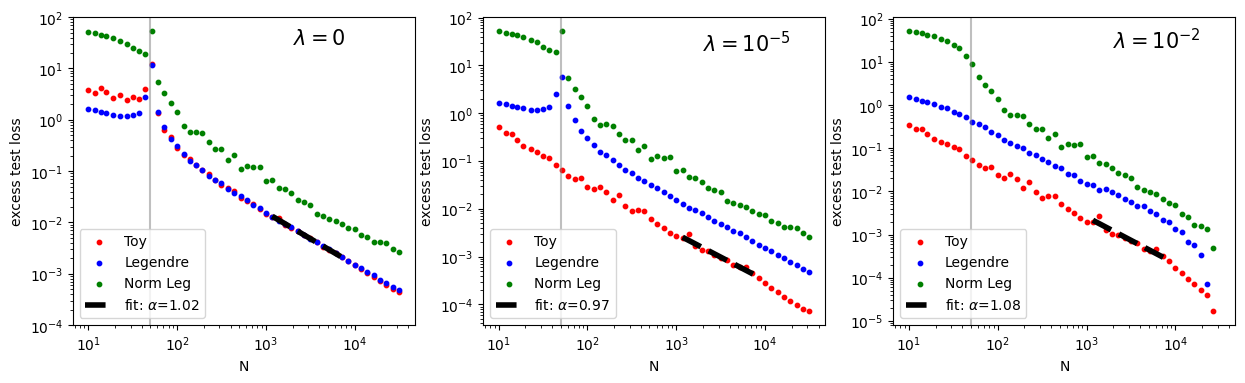

In [31]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

Nmin, Nmax = 1e3, 1e4
mask = (Ns<Nmax) & (Ns>Nmin)
a_fit0, c_fit0 = np.polyfit(np.log(Ns[mask]), np.log(excess_loss_toy[0][mask]), 1)
a_fit1, c_fit1 = np.polyfit(np.log(Ns[mask]), np.log(excess_loss_toy[1e-5][mask]), 1)
a_fit2, c_fit2 = np.polyfit(np.log(Ns[mask]), np.log((excess_loss_toy[1e-2] - excess_loss_toy[1e-2][-1])[mask]), 1)

ax[0].scatter(Ns, excess_loss_toy[0],      s=10, color='r')
ax[0].scatter(Ns, excess_loss_leg[0],      s=10, color='b')
ax[0].scatter(Ns, excess_loss_leg_norm[0], s=10, color='g')
ax[1].scatter(Ns, excess_loss_toy[1e-5],      s=10, color='r')
ax[1].scatter(Ns, excess_loss_leg[1e-5],      s=10, color='b')
ax[1].scatter(Ns, excess_loss_leg_norm[1e-5], s=10, color='g')
ax[2].scatter(Ns, excess_loss_toy[1e-2] - excess_loss_toy[1e-2][-1],      s=10, color='r')
ax[2].scatter(Ns, excess_loss_leg[1e-2] - excess_loss_leg[1e-2][-1],      s=10, color='b')
ax[2].scatter(Ns, excess_loss_leg_norm[1e-2] - excess_loss_leg_norm[1e-2][-1], s=10, color='g')
ax[0].plot(Ns[mask], np.exp(c_fit0) * Ns[mask]**a_fit0, 'k--', lw=4)
ax[1].plot(Ns[mask], np.exp(c_fit1) * Ns[mask]**a_fit1, 'k--', lw=4)
ax[2].plot(Ns[mask], np.exp(c_fit2) * Ns[mask]**a_fit2, 'k--', lw=4)
print(f'floor = {excess_loss_leg_norm[1e-2][-1]}')
ax[0].set_ylim(1e-4, 1e2)
for i in [0,1,2]:
    ax[i].set_xlabel('N'); ax[i].set_ylabel('excess test loss')
    ax[i].set_xscale('log'); ax[i].set_yscale('log')
    ax[i].axvline(50, color='gray', alpha=0.5)
    ax[i].legend([r'Toy', r'Legendre', r'Norm Leg' ])
ax[0].legend([r'Toy', r'Legendre', r'Norm Leg', rf'fit: $\alpha$={-a_fit0:.2f}',], loc='lower left')
ax[1].legend([r'Toy', r'Legendre', r'Norm Leg', rf'fit: $\alpha$={-a_fit1:.2f}',], loc='lower left')
ax[2].legend([r'Toy', r'Legendre', r'Norm Leg', rf'fit: $\alpha$={-a_fit2:.2f}',], loc='lower left')
ax[0].text(2e3, 3e1, r'$\lambda=0$', size=15)
ax[1].text(2e3, 2e1, r'$\lambda=10^{-5}$', size=15)
ax[2].text(2e3, 2e1, r'$\lambda=10^{-2}$', size=15)

## Check just Toy spectra, varying slope, underparameterized

In [94]:
##########################
## Toy Spectrum ~ k^-a ##
##########################
rng = np.random.default_rng(0)

P = 50          # feature dimension
a = 8.           # spectral decay exponent
a_s = np.array([1.2, 1.5, 2, 3])
sigma = 0.5       # noise std

k = np.arange(1, P + 1)
lam = k ** (-a)     # Sigma = diag(lam)
lams = [k ** (-a) for a in a_s]


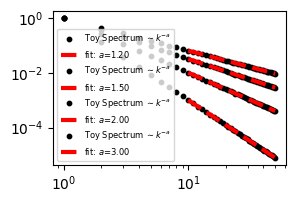

In [95]:
# Plot Spectra
kmin, kmax = 10, 50
mask = (k >= kmin) & (k <= kmax)
mask2 = (k >= 1) & (k <= 5)


plt.figure(figsize=(3,2))
a_fits, c_fits = [], []
for i in range(len(a_s)): 
    a_fit, c_fit = np.polyfit(np.log(k[mask]), np.log(lams[i][mask]), 1)
    a_fits.append(a_fit); c_fits.append(c_fit)
    plt.scatter(k, lams[i], s=10, color='k')
    plt.plot(k[mask], np.exp(c_fit) * k[mask]**a_fit, 'r--', lw=3)
plt.xscale('log'); plt.yscale('log')
plt.legend([r'Toy Spectrum $\sim k^{-a}$', 
            f'fit: $a$={-a_fits[0]:.2f}', 
            r'Toy Spectrum $\sim k^{-a}$', 
            f'fit: $a$={-a_fits[1]:.2f}',
            r'Toy Spectrum $\sim k^{-a}$', 
            f'fit: $a$={-a_fits[2]:.2f}',
            r'Toy Spectrum $\sim k^{-a}$', 
            f'fit: $a$={-a_fits[3]:.2f}'
            ], fontsize=6)

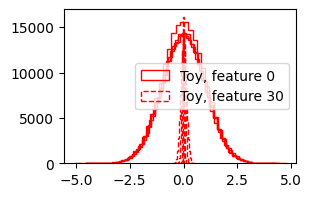

In [112]:
### Plot Samples for a given feature direction ... 

w_true = rng.standard_normal(P)

sigma = 0.5

X_toys, y_toys = [], []
for i, a in enumerate(a_s): 
    X_toy, y_toy = sample(200_000, lams[i], w_true, sigma)
    X_toys.append(X_toy); y_toys.append(y_toy); 

feature = [0, 30]; bins = 50
plt.figure(figsize=(3,2))
for i in range(len(a_s)):
    plt.hist(X_toys[i][:, feature[0]], bins=bins, histtype='step', color='r');
    plt.hist(X_toys[i][:, feature[1]], bins=bins, histtype='step', color='r', linestyle='--');

plt.legend(['Toy, feature 0', 'Toy, feature 30',])

In [117]:
## Run Ridge Regression 
Ns = np.round(np.logspace(1, 5, 50)).astype(int)
n_repeats = lambda N: max(int(10000/N), 100) 

λs = [0, 1e-5, 1e-2]
excess_loss_toy_P50, = {}, 
for λ in λs: 
    print(f'λ = {λ}') 
    excess_loss_toy_P50[λ] = {}
    for i in range(len(a_s)):
        excess_loss_toy_P50[λ][a_s[i]]      = run_regression_sweep(X_toys[i], y_toys[i], Ns, λ, n_repeats, test_size=0.2, w_true=w_true)
    # excess_loss_leg_overparam[λ]      = run_sweep(X_leg, y_leg, w_true, r, Ns, n_repeats)
    # excess_loss_leg_norm_overparam[λ] = run_sweep(X_leg_norm, y_leg_norm, w_true, r, Ns, n_repeats)


λ = 0
      10  |  1.996537
      12  |  1.760366
      15  |  1.562093
      18  |  1.413179
      21  |  1.260901
      26  |  1.180636
      31  |  1.208009
      37  |  1.430044
      45  |  3.999375
      54  |  4.621499
      66  |  0.941000
      79  |  0.525387
      95  |  0.344769
     115  |  0.246197
     139  |  0.171952
     168  |  0.131671
     202  |  0.106222
     244  |  0.081131
     295  |  0.063761
     356  |  0.049353
     429  |  0.039475
     518  |  0.032553
     625  |  0.027206
     754  |  0.021549
     910  |  0.017777
    1099  |  0.015154
    1326  |  0.011948
    1600  |  0.009751
    1931  |  0.007826
    2330  |  0.006686
    2812  |  0.005530
    3393  |  0.004482
    4095  |  0.003651
    4942  |  0.003020
    5964  |  0.002577
    7197  |  0.002080
    8685  |  0.001737
   10481  |  0.001475
   12649  |  0.001237
   15264  |  0.001010
   18421  |  0.000821
   22230  |  0.000688
   26827  |  0.000577
   32375  |  0.000477
   39069  |  0.000384
   4

floor = 0.002111174674913146


Text(10, 1e-06, '$\\lambda=10^{-2}$')

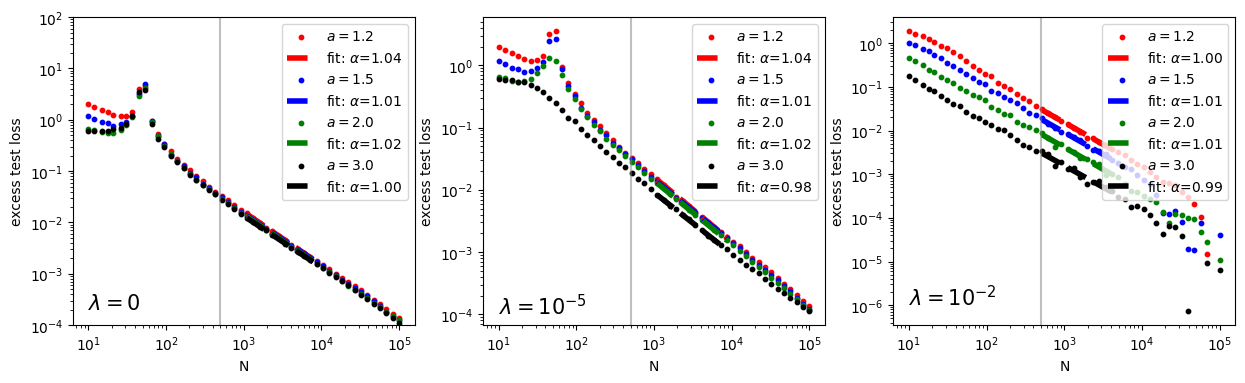

In [123]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

Nmin, Nmax = 1e3, 1e4
mask = (Ns<Nmax) & (Ns>Nmin)
mask2 = (Ns<5e3) & (Ns>5e2)
# a_fit1, c_fit1 = np.polyfit(np.log(Ns[mask]), np.log(excess_loss_toy_P500[1e-5][1.2][mask]), 1)
# a_fit2, c_fit2 = np.polyfit(np.log(Ns[mask]), np.log(excess_loss_toy_P500[1e-2][1.2][mask]), 1)
colors = ['r', 'b', 'g', 'k']
a_fit0s, c_fit0s, a_fit1s, c_fit1s, a_fit2s, c_fit2s = [], [], [], [], [], []
for i, a in enumerate(a_s):
    # Fit 
    a_fit0, c_fit0 = np.polyfit(np.log(Ns[mask]), np.log(excess_loss_toy_P50[0][a][mask]), 1)
    a_fit1, c_fit1 = np.polyfit(np.log(Ns[mask]), np.log(excess_loss_toy_P50[1e-5][a][mask]), 1)
    a_fit2, c_fit2 = np.polyfit(np.log(Ns[mask2]), np.log((excess_loss_toy_P50[1e-2][a] - excess_loss_toy_P50[1e-2][a][-2])[mask2]), 1)
    a_fit0s.append(a_fit0); a_fit1s.append(a_fit1); a_fit2s.append(a_fit2)
    c_fit0s.append(c_fit0); c_fit1s.append(c_fit1); c_fit2s.append(c_fit2)
    # Plot 
    ax[0].scatter(Ns, excess_loss_toy_P50[0][a],      s=10, color=colors[i])
    ax[1].scatter(Ns, excess_loss_toy_P50[1e-5][a],      s=10,  color=colors[i])
    ax[2].scatter(Ns, excess_loss_toy_P50[1e-2][a] - excess_loss_toy_P50[1e-2][a][-2],   s=10,  color=colors[i])
    # Plot Fit 
    ax[0].plot(Ns[mask], np.exp(c_fit0) * Ns[mask]**a_fit0, color=colors[i], linestyle='--', lw=4)
    ax[1].plot(Ns[mask], np.exp(c_fit1) * Ns[mask]**a_fit1, color=colors[i], linestyle='--', lw=4)
    ax[2].plot(Ns[mask2], np.exp(c_fit2) * Ns[mask2]**a_fit2, color=colors[i], linestyle='--', lw=4)

print(f'floor = {excess_loss_toy[1e-2][-1]}')

ax[0].set_ylim(1e-4, 1e2)
for i in [0,1,2]:
    ax[i].set_xlabel('N'); ax[i].set_ylabel('excess test loss')
    ax[i].set_xscale('log'); ax[i].set_yscale('log')
    ax[i].axvline(500, color='gray', alpha=0.5)
ax[0].legend([rf'$a = {a_s[0]}$', rf'fit: $\alpha$={-a_fit0s[0]:.2f}',
              rf'$a = {a_s[1]}$', rf'fit: $\alpha$={-a_fit0s[1]:.2f}',
              rf'$a = {a_s[2]}$', rf'fit: $\alpha$={-a_fit0s[2]:.2f}',
              rf'$a = {a_s[3]}$', rf'fit: $\alpha$={-a_fit0s[3]:.2f}'])
ax[1].legend([rf'$a = {a_s[0]}$', rf'fit: $\alpha$={-a_fit1s[0]:.2f}',
              rf'$a = {a_s[1]}$', rf'fit: $\alpha$={-a_fit1s[1]:.2f}',
              rf'$a = {a_s[2]}$', rf'fit: $\alpha$={-a_fit1s[2]:.2f}',
              rf'$a = {a_s[3]}$', rf'fit: $\alpha$={-a_fit1s[3]:.2f}'])
ax[2].legend([rf'$a = {a_s[0]}$', rf'fit: $\alpha$={-a_fit2s[0]:.2f}',
              rf'$a = {a_s[1]}$', rf'fit: $\alpha$={-a_fit2s[1]:.2f}',
              rf'$a = {a_s[2]}$', rf'fit: $\alpha$={-a_fit2s[2]:.2f}',
              rf'$a = {a_s[3]}$', rf'fit: $\alpha$={-a_fit2s[3]:.2f}'], loc='upper right')
ax[0].text(10, 2e-4, r'$\lambda=0$', size=15)
ax[1].text(10, 1e-4, r'$\lambda=10^{-5}$', size=15)
ax[2].text(10, 1e-6, r'$\lambda=10^{-2}$', size=15)

## Overparameterized Regime

## P = 500

In [134]:
##########################
## Toy Spectrum ~ k^-a ##
##########################
rng = np.random.default_rng(0)

P = 5000          # feature dimension
a = 8.           # spectral decay exponent
a_s = np.array([1.2, 1.5, 2, 3])
sigma = 0.5       # noise std

k = np.arange(1, P + 1)
lam = k ** (-a)     # Sigma = diag(lam)
lams = [k ** (-a) for a in a_s]


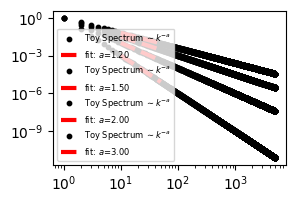

In [135]:
# Plot Spectra
kmin, kmax = 10, 50
mask = (k >= kmin) & (k <= kmax)
mask2 = (k >= 1) & (k <= 5)


plt.figure(figsize=(3,2))
a_fits, c_fits = [], []
for i in range(len(a_s)): 
    a_fit, c_fit = np.polyfit(np.log(k[mask]), np.log(lams[i][mask]), 1)
    a_fits.append(a_fit); c_fits.append(c_fit)
    plt.scatter(k, lams[i], s=10, color='k')
    plt.plot(k[mask], np.exp(c_fit) * k[mask]**a_fit, 'r--', lw=3)
plt.xscale('log'); plt.yscale('log')
plt.legend([r'Toy Spectrum $\sim k^{-a}$', 
            f'fit: $a$={-a_fits[0]:.2f}', 
            r'Toy Spectrum $\sim k^{-a}$', 
            f'fit: $a$={-a_fits[1]:.2f}',
            r'Toy Spectrum $\sim k^{-a}$', 
            f'fit: $a$={-a_fits[2]:.2f}',
            r'Toy Spectrum $\sim k^{-a}$', 
            f'fit: $a$={-a_fits[3]:.2f}'
            ], fontsize=6)

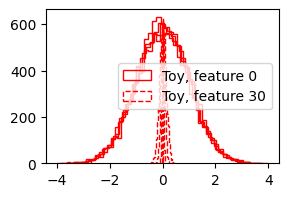

In [136]:
### Plot Samples for a given feature direction ... 

w_true = rng.standard_normal(P)

sigma = 0.5

X_toys, y_toys = [], []
for i, a in enumerate(a_s): 
    X_toy, y_toy = sample(10_000, lams[i], w_true, sigma)
    X_toys.append(X_toy); y_toys.append(y_toy); 

feature = [0, 30]; bins = 50
plt.figure(figsize=(3,2))
for i in range(len(a_s)):
    plt.hist(X_toys[i][:, feature[0]], bins=bins, histtype='step', color='r');
    plt.hist(X_toys[i][:, feature[1]], bins=bins, histtype='step', color='r', linestyle='--');

plt.legend(['Toy, feature 0', 'Toy, feature 30',])

In [137]:
## Run Ridge Regression 
Ns = np.round(np.logspace(1, 3.5, 40)).astype(int)
n_repeats = lambda N: max(int(3000/N), 30) 

λs = [0, 1e-5, 1e-2]
excess_loss_toy_P500, = {}, 
for λ in λs: 
    print(f'λ = {λ}') 
    excess_loss_toy_P500[λ] = {}
    for i in range(len(a_s)):
        excess_loss_toy_P500[λ][a_s[i]]      = run_regression_sweep(X_toys[i], y_toys[i], Ns, λ, n_repeats, test_size=0.2, w_true=w_true)
    # excess_loss_leg_overparam[λ]      = run_sweep(X_leg, y_leg, w_true, r, Ns, n_repeats)
    # excess_loss_leg_norm_overparam[λ] = run_sweep(X_leg_norm, y_leg_norm, w_true, r, Ns, n_repeats)


λ = 0
      10  |  2.961812
      12  |  2.870962
      13  |  2.873481
      16  |  2.804465
      18  |  2.739186
      21  |  2.611376
      24  |  2.588295
      28  |  2.436317
      33  |  2.355811
      38  |  2.372932
      44  |  2.283477
      51  |  2.186682
      59  |  2.046031
      68  |  2.018948
      79  |  1.938552
      92  |  1.811227
     106  |  1.759772
     123  |  1.711645
     143  |  1.613532
     165  |  1.579492
     191  |  1.475531
     222  |  1.392863
     257  |  1.342684
     298  |  1.258008
     346  |  1.163261
     400  |  1.114831
     464  |  1.055670
     538  |  0.978170
     624  |  0.946422
     723  |  0.881458
     838  |  0.814452
     971  |  0.781861
    1125  |  0.736184
    1304  |  0.702853
    1512  |  0.665489
    1752  |  0.636355
    2031  |  0.612763
    2354  |  0.615919
    2728  |  0.633748
    3162  |  0.716426
      10  |  1.131311
      12  |  1.047978
      13  |  1.022364
      16  |  0.975868
      18  |  0.904675
    

In [138]:
excess_loss_toy_P500[0].keys()

dict_keys([1.2, 1.5, 2.0, 3.0])

floor = 0.002111174674913146


Text(800.0, 2.0, '$r=10^{-2}$')

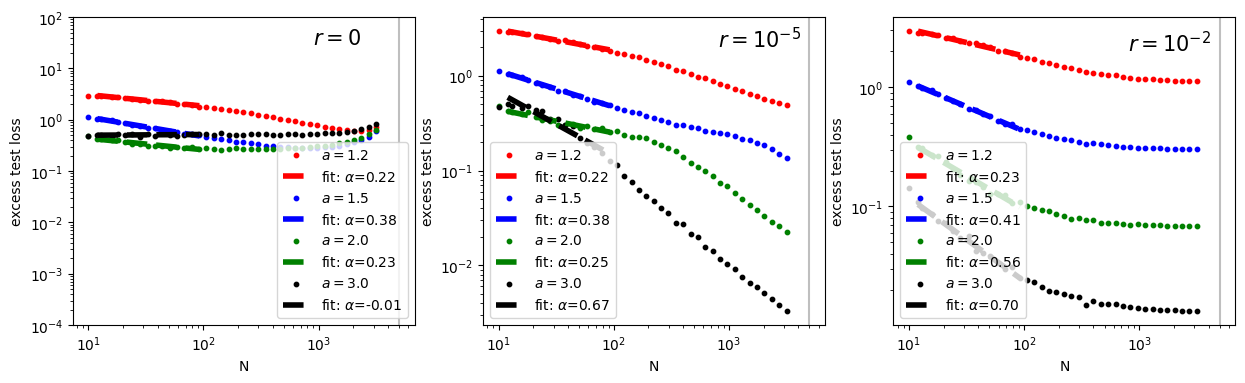

In [140]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

Nmin, Nmax = 1e1, 1e2
mask = (Ns<Nmax) & (Ns>Nmin)
# a_fit0, c_fit0 = np.polyfit(np.log(Ns[mask]), np.log(excess_loss_toy_P500[0][1.2][mask]), 1)
# a_fit1, c_fit1 = np.polyfit(np.log(Ns[mask]), np.log(excess_loss_toy_P500[1e-5][1.2][mask]), 1)
# a_fit2, c_fit2 = np.polyfit(np.log(Ns[mask]), np.log(excess_loss_toy_P500[1e-2][1.2][mask]), 1)
colors = ['r', 'b', 'g', 'k']
a_fit0s, c_fit0s, a_fit1s, c_fit1s, a_fit2s, c_fit2s = [], [], [], [], [], []
for i, a in enumerate(a_s):
    # Fit 
    a_fit0, c_fit0 = np.polyfit(np.log(Ns[mask]), np.log(excess_loss_toy_P500[0][a][mask]), 1)
    a_fit1, c_fit1 = np.polyfit(np.log(Ns[mask]), np.log(excess_loss_toy_P500[1e-5][a][mask]), 1)
    a_fit2, c_fit2 = np.polyfit(np.log(Ns[mask]), np.log(excess_loss_toy_P500[1e-2][a][mask]), 1)
    a_fit0s.append(a_fit0); a_fit1s.append(a_fit1); a_fit2s.append(a_fit2)
    c_fit0s.append(c_fit0); c_fit1s.append(c_fit1); c_fit2s.append(c_fit2)
    # Plot 
    ax[0].scatter(Ns, excess_loss_toy_P500[0][a],      s=10, color=colors[i])
    ax[1].scatter(Ns, excess_loss_toy_P500[1e-5][a],      s=10,  color=colors[i])
    ax[2].scatter(Ns, excess_loss_toy_P500[1e-2][a],      s=10,  color=colors[i])
    # Plot Fit 
    ax[0].plot(Ns[mask], np.exp(c_fit0) * Ns[mask]**a_fit0, color=colors[i], linestyle='--', lw=4)
    ax[1].plot(Ns[mask], np.exp(c_fit1) * Ns[mask]**a_fit1, color=colors[i], linestyle='--', lw=4)
    ax[2].plot(Ns[mask], np.exp(c_fit2) * Ns[mask]**a_fit2, color=colors[i], linestyle='--', lw=4)

print(f'floor = {excess_loss_toy[1e-2][-1]}')

ax[0].set_ylim(1e-4, 1e2)
for i in [0,1,2]:
    ax[i].set_xlabel('N'); ax[i].set_ylabel('excess test loss')
    ax[i].set_xscale('log'); ax[i].set_yscale('log')
    ax[i].axvline(5000, color='gray', alpha=0.5)
ax[0].legend([rf'$a = {a_s[0]}$', rf'fit: $\alpha$={-a_fit0s[0]:.2f}',
              rf'$a = {a_s[1]}$', rf'fit: $\alpha$={-a_fit0s[1]:.2f}',
              rf'$a = {a_s[2]}$', rf'fit: $\alpha$={-a_fit0s[2]:.2f}',
              rf'$a = {a_s[3]}$', rf'fit: $\alpha$={-a_fit0s[3]:.2f}'])
ax[1].legend([rf'$a = {a_s[0]}$', rf'fit: $\alpha$={-a_fit1s[0]:.2f}',
              rf'$a = {a_s[1]}$', rf'fit: $\alpha$={-a_fit1s[1]:.2f}',
              rf'$a = {a_s[2]}$', rf'fit: $\alpha$={-a_fit1s[2]:.2f}',
              rf'$a = {a_s[3]}$', rf'fit: $\alpha$={-a_fit1s[3]:.2f}'])
ax[2].legend([rf'$a = {a_s[0]}$', rf'fit: $\alpha$={-a_fit2s[0]:.2f}',
              rf'$a = {a_s[1]}$', rf'fit: $\alpha$={-a_fit2s[1]:.2f}',
              rf'$a = {a_s[2]}$', rf'fit: $\alpha$={-a_fit2s[2]:.2f}',
              rf'$a = {a_s[3]}$', rf'fit: $\alpha$={-a_fit2s[3]:.2f}'], loc='lower left')
ax[0].text(9e2, 3e1, r'$r=0$', size=15)
ax[1].text(8e2, 2e0, r'$r=10^{-5}$', size=15)
ax[2].text(8e2, 2e0, r'$r=10^{-2}$', size=15)

floor = 0.002111174674913146


Text(800.0, 2.0, '$r=10^{-2}$')

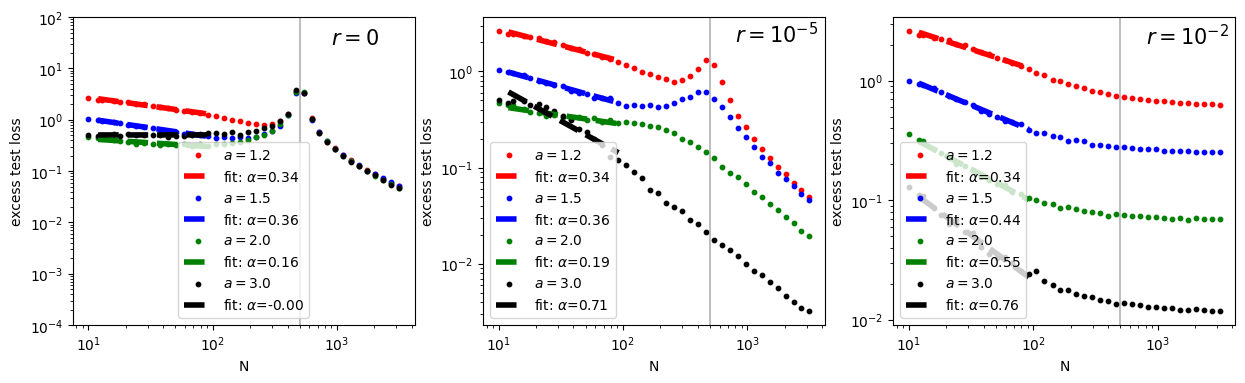

In [133]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

Nmin, Nmax = 1e1, 1e2
mask = (Ns<Nmax) & (Ns>Nmin)
# a_fit0, c_fit0 = np.polyfit(np.log(Ns[mask]), np.log(excess_loss_toy_P500[0][1.2][mask]), 1)
# a_fit1, c_fit1 = np.polyfit(np.log(Ns[mask]), np.log(excess_loss_toy_P500[1e-5][1.2][mask]), 1)
# a_fit2, c_fit2 = np.polyfit(np.log(Ns[mask]), np.log(excess_loss_toy_P500[1e-2][1.2][mask]), 1)
colors = ['r', 'b', 'g', 'k']
a_fit0s, c_fit0s, a_fit1s, c_fit1s, a_fit2s, c_fit2s = [], [], [], [], [], []
for i, a in enumerate(a_s):
    # Fit 
    a_fit0, c_fit0 = np.polyfit(np.log(Ns[mask]), np.log(excess_loss_toy_P500[0][a][mask]), 1)
    a_fit1, c_fit1 = np.polyfit(np.log(Ns[mask]), np.log(excess_loss_toy_P500[1e-5][a][mask]), 1)
    a_fit2, c_fit2 = np.polyfit(np.log(Ns[mask]), np.log(excess_loss_toy_P500[1e-2][a][mask]), 1)
    a_fit0s.append(a_fit0); a_fit1s.append(a_fit1); a_fit2s.append(a_fit2)
    c_fit0s.append(c_fit0); c_fit1s.append(c_fit1); c_fit2s.append(c_fit2)
    # Plot 
    ax[0].scatter(Ns, excess_loss_toy_P500[0][a],      s=10, color=colors[i])
    ax[1].scatter(Ns, excess_loss_toy_P500[1e-5][a],      s=10,  color=colors[i])
    ax[2].scatter(Ns, excess_loss_toy_P500[1e-2][a],      s=10,  color=colors[i])
    # Plot Fit 
    ax[0].plot(Ns[mask], np.exp(c_fit0) * Ns[mask]**a_fit0, color=colors[i], linestyle='--', lw=4)
    ax[1].plot(Ns[mask], np.exp(c_fit1) * Ns[mask]**a_fit1, color=colors[i], linestyle='--', lw=4)
    ax[2].plot(Ns[mask], np.exp(c_fit2) * Ns[mask]**a_fit2, color=colors[i], linestyle='--', lw=4)

print(f'floor = {excess_loss_toy[1e-2][-1]}')

ax[0].set_ylim(1e-4, 1e2)
for i in [0,1,2]:
    ax[i].set_xlabel('N'); ax[i].set_ylabel('excess test loss')
    ax[i].set_xscale('log'); ax[i].set_yscale('log')
    ax[i].axvline(500, color='gray', alpha=0.5)
ax[0].legend([rf'$a = {a_s[0]}$', rf'fit: $\alpha$={-a_fit0s[0]:.2f}',
              rf'$a = {a_s[1]}$', rf'fit: $\alpha$={-a_fit0s[1]:.2f}',
              rf'$a = {a_s[2]}$', rf'fit: $\alpha$={-a_fit0s[2]:.2f}',
              rf'$a = {a_s[3]}$', rf'fit: $\alpha$={-a_fit0s[3]:.2f}'])
ax[1].legend([rf'$a = {a_s[0]}$', rf'fit: $\alpha$={-a_fit1s[0]:.2f}',
              rf'$a = {a_s[1]}$', rf'fit: $\alpha$={-a_fit1s[1]:.2f}',
              rf'$a = {a_s[2]}$', rf'fit: $\alpha$={-a_fit1s[2]:.2f}',
              rf'$a = {a_s[3]}$', rf'fit: $\alpha$={-a_fit1s[3]:.2f}'])
ax[2].legend([rf'$a = {a_s[0]}$', rf'fit: $\alpha$={-a_fit2s[0]:.2f}',
              rf'$a = {a_s[1]}$', rf'fit: $\alpha$={-a_fit2s[1]:.2f}',
              rf'$a = {a_s[2]}$', rf'fit: $\alpha$={-a_fit2s[2]:.2f}',
              rf'$a = {a_s[3]}$', rf'fit: $\alpha$={-a_fit2s[3]:.2f}'], loc='lower left')
ax[0].text(9e2, 3e1, r'$r=0$', size=15)
ax[1].text(8e2, 2e0, r'$r=10^{-5}$', size=15)
ax[2].text(8e2, 2e0, r'$r=10^{-2}$', size=15)

floor = 0.002111174674913146


Text(800.0, 0.1, '$r=10^{-2}$')

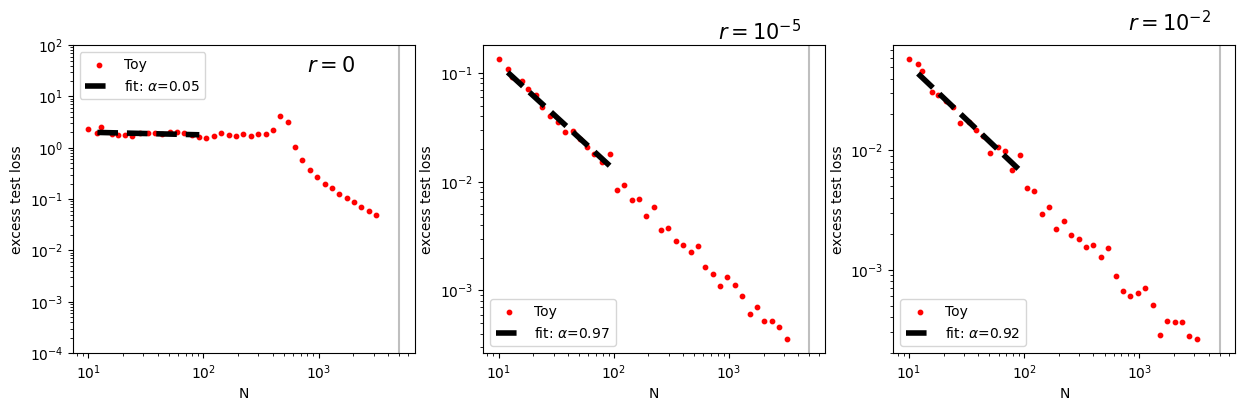

In [39]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

Nmin, Nmax = 1e1, 1e2
mask = (Ns<Nmax) & (Ns>Nmin)
a_fit0, c_fit0 = np.polyfit(np.log(Ns[mask]), np.log(excess_loss_toy_P500[0][mask]), 1)
a_fit1, c_fit1 = np.polyfit(np.log(Ns[mask]), np.log(excess_loss_toy_P500[1e-5][mask]), 1)
a_fit2, c_fit2 = np.polyfit(np.log(Ns[mask]), np.log(excess_loss_toy_P500[1e-2][mask]), 1)

ax[0].scatter(Ns, excess_loss_toy_P500[0],      s=10, color='r')
ax[1].scatter(Ns, excess_loss_toy_P500[1e-5],      s=10, color='r')
ax[2].scatter(Ns, excess_loss_toy_P500[1e-2],      s=10, color='r')

print(f'floor = {excess_loss_toy[1e-2][-1]}')
ax[0].plot(Ns[mask], np.exp(c_fit0) * Ns[mask]**a_fit0, 'k--', lw=4)
ax[1].plot(Ns[mask], np.exp(c_fit1) * Ns[mask]**a_fit1, 'k--', lw=4)
ax[2].plot(Ns[mask], np.exp(c_fit2) * Ns[mask]**a_fit2, 'k--', lw=4)
ax[0].set_ylim(1e-4, 1e2)
for i in [0,1,2]:
    ax[i].set_xlabel('N'); ax[i].set_ylabel('excess test loss')
    ax[i].set_xscale('log'); ax[i].set_yscale('log')
    ax[i].axvline(5000, color='gray', alpha=0.5)
    ax[i].legend([r'Toy', r'Legendre', r'Norm Leg' ])
ax[0].legend([r'Toy', rf'fit: $\alpha$={-a_fit0:.2f}',])
ax[1].legend([r'Toy', rf'fit: $\alpha$={-a_fit1:.2f}',])
ax[2].legend([r'Toy', rf'fit: $\alpha$={-a_fit2:.2f}',])
ax[0].text(8e2, 3e1, r'$r=0$', size=15)
ax[1].text(8e2, 2e-1, r'$r=10^{-5}$', size=15)
ax[2].text(8e2, 1e-1, r'$r=10^{-2}$', size=15)

## P = 5000

In [42]:
##########################
## Toy Spectrum ~ k^-a ##
##########################
rng = np.random.default_rng(0)

P = 5000          # feature dimension
a = 8.0           # spectral decay exponent
sigma = 0.5       # noise std

k = np.arange(1, P + 1)
lam = k ** (-a)     # Sigma = diag(lam)


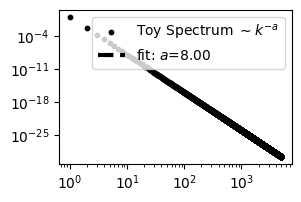

In [43]:
# Plot Spectra
kmin, kmax = 10, 50
mask = (k >= kmin) & (k <= kmax)
mask2 = (k >= 1) & (k <= 5)

a_fit, c_fit = np.polyfit(np.log(k[mask]), np.log(lam[mask]), 1)
plt.figure(figsize=(3,2))
plt.scatter(k, lam, s=10, color='k')
plt.plot(k[mask], np.exp(c_fit) * k[mask]**a_fit, 'k--', lw=3)
plt.xscale('log'); plt.yscale('log')
plt.legend([r'Toy Spectrum $\sim k^{-a}$', 
            # 'Legendre Spectrum','Normalized Legendre Spectrum',
            f'fit: $a$={-a_fit:.2f}', 
            # f'fit: $a$={-a_leg_fit:.2f}',
            # f'fit: $a$={-a_leg_fit2:.2f}'
            ])

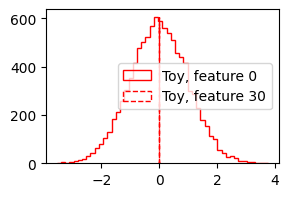

In [44]:
### Plot Samples for a given feature direction ... 

w_true = rng.standard_normal(P)

sigma = 0.5

X_toy, y_toy = sample(10_000, lam, w_true, sigma)

feature = [0, 30]; bins = 50
plt.figure(figsize=(3,2))
plt.hist(X_toy[:, feature[0]], bins=bins, histtype='step', color='r');
plt.hist(X_toy[:, feature[1]], bins=bins, histtype='step', color='r', linestyle='--');

plt.legend(['Toy, feature 0', 'Toy, feature 30',])

In [45]:
## Run Ridge Regression 
Ns = np.round(np.logspace(1, 3.5, 40)).astype(int)
n_repeats = lambda N: max(int(2000/N), 20) 

λs = [0, 1e-5, 1e-2]
excess_loss_toy_P5000, = {}, 
for λ in λs: 
    print(f'λ = {λ}')
    excess_loss_toy_P5000[λ]      = run_regression_sweep(X_toy, y_toy, Ns, λ, n_repeats, test_size=0.2, w_true=w_true)
    # excess_loss_leg_overparam[r]      = run_sweep(X_leg, y_leg, w_true, r, Ns, n_repeats)
    # excess_loss_leg_norm_overparam[r] = run_sweep(X_leg_norm, y_leg_norm, w_true, r, Ns, n_repeats)


λ = 0
      10  |  1.679140
      12  |  1.853452
      13  |  1.872841
      16  |  1.993222
      18  |  1.699834
      21  |  1.802183
      24  |  1.842090
      28  |  1.964642
      33  |  1.726462
      38  |  1.896890
      44  |  1.673935
      51  |  1.863270
      59  |  2.005335
      68  |  1.850772
      79  |  1.660829
      92  |  1.710807
     106  |  1.664602
     123  |  1.653161
     143  |  1.630336
     165  |  1.738062
     191  |  1.844254
     222  |  1.780557
     257  |  1.812781
     298  |  1.680339
     346  |  1.608784
     400  |  1.708510
     464  |  1.723228
     538  |  1.714052
     624  |  1.589036
     723  |  1.644562
     838  |  1.706764
     971  |  1.657596
    1125  |  1.634454
    1304  |  1.494119
    1512  |  1.299820
    1752  |  1.395722
    2031  |  1.199183
    2354  |  1.052547
    2728  |  0.744958
    3162  |  0.633571
λ = 1e-05
      10  |  0.141411
      12  |  0.105709
      13  |  0.094545
      16  |  0.084097
      18  |  0.0

floor = 0.11018507294360413


Text(800.0, 2.0, '$r=10^{-2}$')

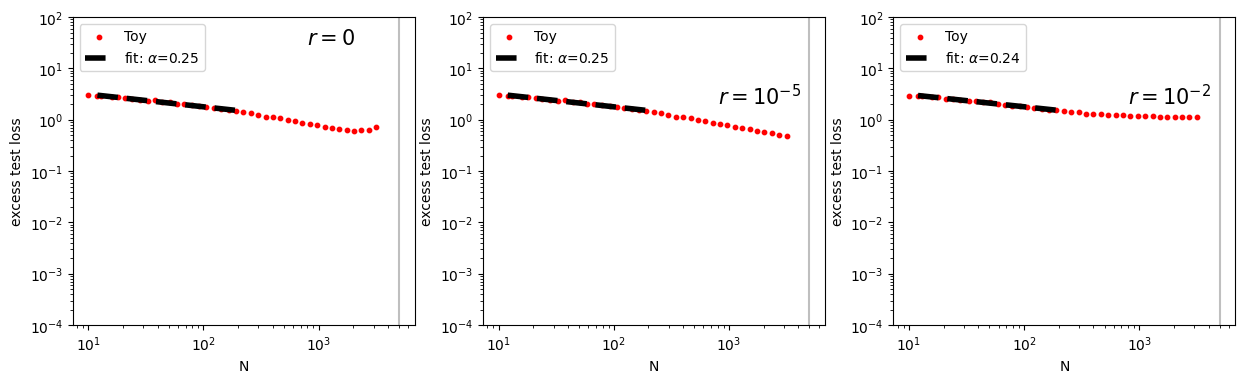

In [19]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

Nmin, Nmax = 1e1, 2e2
mask = (Ns<Nmax) & (Ns>Nmin)
a_fit0, c_fit0 = np.polyfit(np.log(Ns[mask]), np.log(excess_loss_toy_P5000[0][mask]), 1)
a_fit1, c_fit1 = np.polyfit(np.log(Ns[mask]), np.log(excess_loss_toy_P5000[1e-5][mask]), 1)
a_fit2, c_fit2 = np.polyfit(np.log(Ns[mask]), np.log(excess_loss_toy_P5000[1e-2][mask]), 1)

ax[0].scatter(Ns, excess_loss_toy_P5000[0],      s=10, color='r')

ax[1].scatter(Ns, excess_loss_toy_P5000[1e-5],      s=10, color='r')
# ax[1].scatter(Ns, excess_loss_leg[1e-5],      s=10, color='b')
# ax[1].scatter(Ns, excess_loss_leg_norm[1e-5], s=10, color='g')
ax[2].scatter(Ns, excess_loss_toy_P5000[1e-2],      s=10, color='r')
# ax[2].scatter(Ns, excess_loss_leg[1e-2],      s=10, color='b')
# ax[2].scatter(Ns, excess_loss_leg_norm[1e-2], s=10, color='g')
print(f'floor = {excess_loss_toy[1e-2][-1]}')
ax[0].plot(Ns[mask], np.exp(c_fit0) * Ns[mask]**a_fit0, 'k--', lw=4)
ax[1].plot(Ns[mask], np.exp(c_fit1) * Ns[mask]**a_fit1, 'k--', lw=4) 
ax[2].plot(Ns[mask], np.exp(c_fit2) * Ns[mask]**a_fit2, 'k--', lw=4)
ax[0].set_ylim(1e-4, 1e2)
for i in [0,1,2]:
    ax[i].set_ylim(1e-4, 1e2)
    ax[i].set_xlabel('N'); ax[i].set_ylabel('excess test loss')
    ax[i].set_xscale('log'); ax[i].set_yscale('log')
    ax[i].axvline(5000, color='gray', alpha=0.5)
    ax[i].legend([r'Toy', r'Legendre', r'Norm Leg' ])
ax[0].legend([r'Toy', rf'fit: $\alpha$={-a_fit0:.2f}',])
ax[1].legend([r'Toy', rf'fit: $\alpha$={-a_fit1:.2f}',])
ax[2].legend([r'Toy', rf'fit: $\alpha$={-a_fit2:.2f}',])
ax[0].text(8e2, 3e1, r'$r=0$', size=15)
ax[1].text(8e2, 2e0, r'$r=10^{-5}$', size=15)
ax[2].text(8e2, 2e0, r'$r=10^{-2}$', size=15)

floor = 0.002111174674913146


Text(800.0, 2.0, '$r=10^{-2}$')

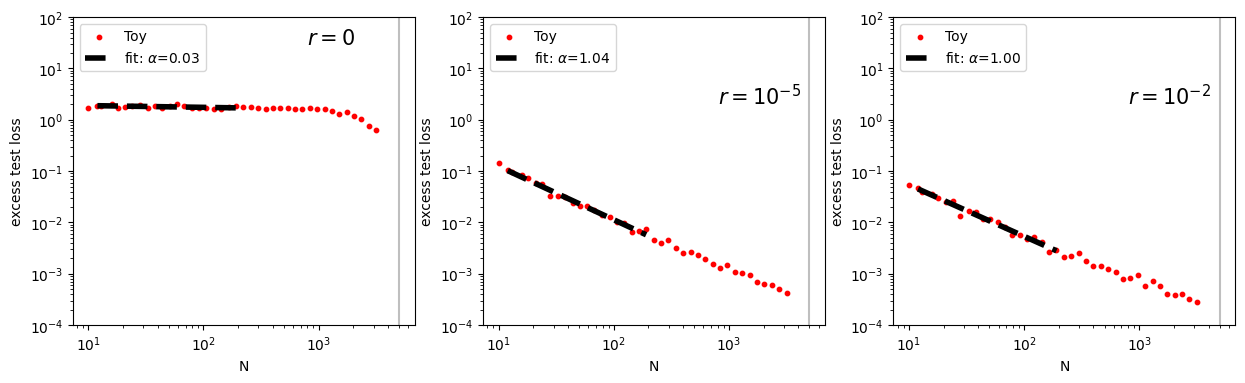

In [46]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

Nmin, Nmax = 1e1, 2e2
mask = (Ns<Nmax) & (Ns>Nmin)
a_fit0, c_fit0 = np.polyfit(np.log(Ns[mask]), np.log(excess_loss_toy_P5000[0][mask]), 1)
a_fit1, c_fit1 = np.polyfit(np.log(Ns[mask]), np.log(excess_loss_toy_P5000[1e-5][mask]), 1)
a_fit2, c_fit2 = np.polyfit(np.log(Ns[mask]), np.log(excess_loss_toy_P5000[1e-2][mask]), 1)

ax[0].scatter(Ns, excess_loss_toy_P5000[0],      s=10, color='r')

ax[1].scatter(Ns, excess_loss_toy_P5000[1e-5],      s=10, color='r')
# ax[1].scatter(Ns, excess_loss_leg[1e-5],      s=10, color='b')
# ax[1].scatter(Ns, excess_loss_leg_norm[1e-5], s=10, color='g')
ax[2].scatter(Ns, excess_loss_toy_P5000[1e-2],      s=10, color='r')
# ax[2].scatter(Ns, excess_loss_leg[1e-2],      s=10, color='b')
# ax[2].scatter(Ns, excess_loss_leg_norm[1e-2], s=10, color='g')
print(f'floor = {excess_loss_toy[1e-2][-1]}')
ax[0].plot(Ns[mask], np.exp(c_fit0) * Ns[mask]**a_fit0, 'k--', lw=4)
ax[1].plot(Ns[mask], np.exp(c_fit1) * Ns[mask]**a_fit1, 'k--', lw=4) 
ax[2].plot(Ns[mask], np.exp(c_fit2) * Ns[mask]**a_fit2, 'k--', lw=4)
ax[0].set_ylim(1e-4, 1e2)
for i in [0,1,2]:
    ax[i].set_ylim(1e-4, 1e2)
    ax[i].set_xlabel('N'); ax[i].set_ylabel('excess test loss')
    ax[i].set_xscale('log'); ax[i].set_yscale('log')
    ax[i].axvline(5000, color='gray', alpha=0.5)
    ax[i].legend([r'Toy', r'Legendre', r'Norm Leg' ])
ax[0].legend([r'Toy', rf'fit: $\alpha$={-a_fit0:.2f}',])
ax[1].legend([r'Toy', rf'fit: $\alpha$={-a_fit1:.2f}',])
ax[2].legend([r'Toy', rf'fit: $\alpha$={-a_fit2:.2f}',])
ax[0].text(8e2, 3e1, r'$r=0$', size=15)
ax[1].text(8e2, 2e0, r'$r=10^{-5}$', size=15)
ax[2].text(8e2, 2e0, r'$r=10^{-2}$', size=15)

# N = 10,000 (reproduce Cengiz, Fig 5)

In [88]:
## ===== Shared config =====
rng = np.random.default_rng(0)

N = 10000        # feature dimension
sigma = 0        # label noise
ridge = 1e-4     # ridge parameter (lambda)

k = np.arange(1, N + 1)
Ps = np.unique(np.round(np.logspace(0, 3.5, 80)).astype(int))   # training sizes to sweep

In [89]:
def ridge_scaling_sweep(a, r, ridge, n_samples, n_repeats):
    """Gaussian features (capacity exponent a) + structured unit-norm teacher (source exponent r).
    Sample data, sweep training size P, return test losses."""
    lam = k.astype(float) ** (-a)                          # spectrum for this capacity exponent
    w_true = k.astype(float) ** (-(1 + a * (2*r - 1)) / 2)
    w_true /= np.linalg.norm(w_true)                       # ||w|| = 1
    X, y = sample(n_samples, lam, w_true, sigma)
    return run_regression_sweep(X, y, Ps, ridge, n_repeats, test_size=0.2, w_true=w_true)

In [91]:
n_reps = lambda P: max(int(5000 / P), 50)
a_s = [1.1, 1.8, 2.5, 6]
losses_1em4 = {}
losses_1em10 = {}

for r in [1.8, 0.5]:
    losses_1em4[r], losses_1em10[r] = {}, {}
    for a in a_s:
        print(f'r = {r}, a = {a}')
        losses_1em4[r][a] = ridge_scaling_sweep(a, r, ridge = 1e-4, n_samples=10_000, n_repeats=n_reps)
        losses_1em10[r][a]= ridge_scaling_sweep(a, r, ridge = 1e-10, n_samples=10_000, n_repeats=n_reps)

r = 1.8, a = 1.1
       1  |  0.760723
       2  |  0.608304
       3  |  0.495646
       4  |  0.400783
       5  |  0.333804
       6  |  0.271601
       7  |  0.238754
       8  |  0.203888
       9  |  0.166073
      10  |  0.150681
      12  |  0.110282
      13  |  0.097481
      14  |  0.087629
      16  |  0.074269
      17  |  0.068180
      19  |  0.052681
      21  |  0.045846
      24  |  0.035571
      26  |  0.031205
      29  |  0.024368
      32  |  0.020257
      36  |  0.015006
      39  |  0.013720
      44  |  0.009837
      48  |  0.008762
      53  |  0.006811
      59  |  0.005455
      66  |  0.004070
      73  |  0.003244
      80  |  0.002728
      89  |  0.002090
      99  |  0.001605
     109  |  0.001307
     121  |  0.001041
     134  |  0.000800
     148  |  0.000636
     164  |  0.000501
     182  |  0.000386
     201  |  0.000296
     223  |  0.000240
     247  |  0.000184
     273  |  0.000142
     303  |  0.000105
     335  |  0.000083
     371  |  0.

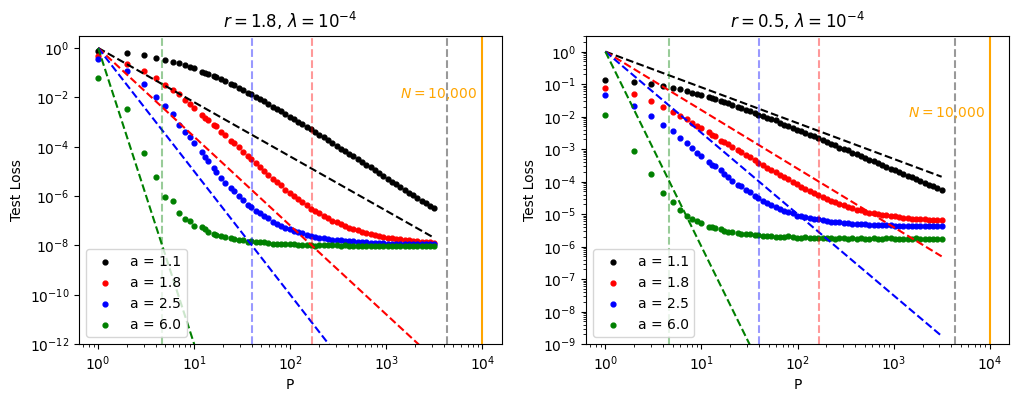

In [132]:
## ==== Plot losses[r][a] ==== ## 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

styles = ['k--', 'r--', 'b--', 'g--']

r = 1.8
axes[0].scatter(Ps, losses_1em4[r][1.1], s=12, color='k')
axes[0].scatter(Ps, losses_1em4[r][1.8], s=12, color='r')
axes[0].scatter(Ps, losses_1em4[r][2.5], s=12, color='b')
axes[0].scatter(Ps, losses_1em4[r][6.0], s=12, color='g')
[axes[0].plot(Ps, Ps**(-2.*a), styles[i]) for i, a in enumerate(a_s)]
[axes[0].axvline((1e-4)**(-1/a), color=styles[i][0], ls='--', alpha=0.4) for i, a in enumerate(a_s)]
axes[0].axvline(10_000, color='orange')
axes[0].text(1.4e3, 1e-2, r'$N = 10{,}000$', color='orange')
r = 0.5
axes[1].scatter(Ps, losses_1em4[r][1.1], s=12, color='k')
axes[1].scatter(Ps, losses_1em4[r][1.8], s=12, color='r')
axes[1].scatter(Ps, losses_1em4[r][2.5], s=12, color='b')
axes[1].scatter(Ps, losses_1em4[r][6.0], s=12, color='g')
[axes[1].plot(Ps, Ps**(-2.*a*r), styles[i]) for i, a in enumerate(a_s)]
[axes[1].axvline((1e-4)**(-1/a), color=styles[i][0], ls='--', alpha=0.4) for i, a in enumerate(a_s)]
axes[1].axvline(10_000, color='orange')
axes[1].text(1.4e3, 1e-2, r'$N = 10{,}000$', color='orange')

for ax, r in zip(axes, [1.8, 0.5]): 
    # [ax.plot(Ps, Ps**(-2*a)) for a in a_s]
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('P'); ax.set_ylabel('Test Loss')
    ax.set_title(rf'$r = {r}, \, \lambda = 10^{{-4}}$')

axes[0].set_ylim(1e-12, 3e0)
axes[1].set_ylim(1e-9, 3e0)
axes[0].legend([f'a = 1.1', f'a = 1.8', f'a = 2.5', r'a = 6.0'], loc='lower left')
axes[1].legend([f'a = 1.1', f'a = 1.8', f'a = 2.5', r'a = 6.0'])

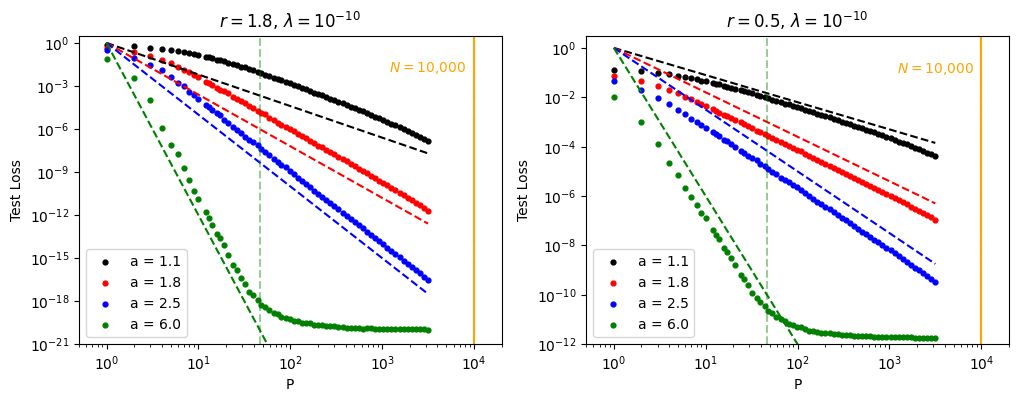

In [133]:
## ==== Plot losses[r][a] ==== ## 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

styles = ['k--', 'r--', 'b--', 'g--']

r = 1.8
axes[0].scatter(Ps, losses_1em10[r][1.1], s=12, color='k')
axes[0].scatter(Ps, losses_1em10[r][1.8], s=12, color='r')
axes[0].scatter(Ps, losses_1em10[r][2.5], s=12, color='b')
axes[0].scatter(Ps, losses_1em10[r][6.0], s=12, color='g')
[axes[0].plot(Ps, Ps**(-2.*a), styles[i]) for i, a in enumerate(a_s)]
[axes[0].axvline((1e-10)**(-1/a), color=styles[i][0], ls='--', alpha=0.4) for i, a in enumerate(a_s)]
axes[0].axvline(10_000, color='orange')
axes[0].text(1.2e3, 1e-2, r'$N = 10{,}000$', color='orange')
r = 0.5
axes[1].scatter(Ps, losses_1em10[r][1.1], s=12, color='k')
axes[1].scatter(Ps, losses_1em10[r][1.8], s=12, color='r')
axes[1].scatter(Ps, losses_1em10[r][2.5], s=12, color='b')
axes[1].scatter(Ps, losses_1em10[r][6.0], s=12, color='g')
[axes[1].plot(Ps, Ps**(-2.*a*r), styles[i]) for i, a in enumerate(a_s)]
[axes[1].axvline((1e-10)**(-1/a), color=styles[i][0], ls='--', alpha=0.4) for i, a in enumerate(a_s)]
axes[1].axvline(10_000, color='orange')
axes[1].text(1.2e3, 1e-1, r'$N = 10{,}000$', color='orange')



for ax, r in zip(axes, [1.8, 0.5]): 
    # [ax.plot(Ps, Ps**(-2*a)) for a in a_s]
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('P'); ax.set_ylabel('Test Loss')
    ax.set_title(rf'$r = {r}, \, \lambda = 10^{{-10}}$')
    ax.set_xlim(5e-1, 2e4)

axes[0].set_ylim(1e-21, 3e0)
axes[1].set_ylim(1e-12, 3e0)
axes[0].legend([f'a = 1.1', f'a = 1.8', f'a = 2.5', r'a = 6.0'])
axes[1].legend([f'a = 1.1', f'a = 1.8', f'a = 2.5', r'a = 6.0'])

In [105]:
(1e-4)**(-1/1.1)

4328.761281083057

In [126]:
(1e-10)**(-1/2.5)

10000.000000000005